# Beamline Optimization - Initialization
This notebook performs sequential optimization of the UH beamline using custom modules and beam parameters.

Help for associated beamline element indexing: image.png

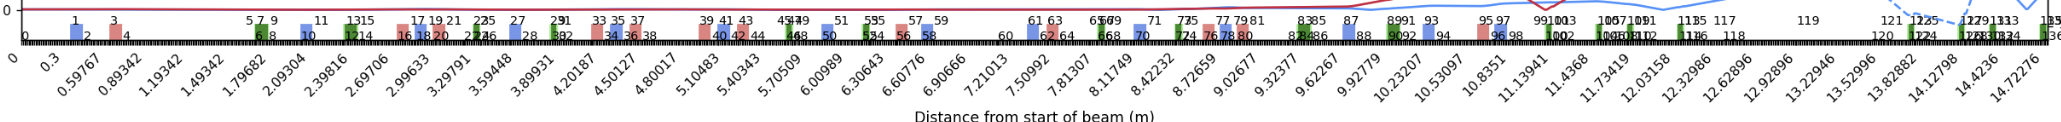

In [1]:
%load_ext autotime
import os, sys
from pprint import pprint
# pprint(sys.path)

current_dir = os.path.abspath(os.getcwd())

project_root = os.path.abspath(os.path.join(current_dir, '..'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)
# pprint(sys.path)
# from backend.beamline import *
from beamline import *

time: 5.19 s (started: 2026-07-02 15:48:36 -10:00)


In [2]:
%load_ext autotime
# Import Python modules
%matplotlib ipympl
import sys
import time
from pathlib import Path
import numpy as np
import pandas as pd
import sympy as sp
import sympy.plotting as plot

# Import Beam Dynamics modules
from ebeam import beam
from beamline import lattice, Beamline
from schematic import draw_beamline
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer
from AlgebraicOptimization import AlgebraicOpti

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 9.34 s (started: 2026-06-21 21:08:09 -10:00)


In [4]:
%load_ext autotime
# Initial Beam Parameters
Energy = 40  # MeV
f = 2856e6  # Hz
bunch_spread = 2  # ps
energy_std_percent = 0.5  # 0.3 % Energy spread from M. Hadmack Rev. Sci. Instrum. 84, 063302 (2013); doi: 10.1063/1.4809938 
h = 5e9  # 1/s

epsilon_n = 8  # pi.mm.mrad
x_std = 0.8  # mm
y_std = 0.8  # mm
nb_particles = 1000

relat = lattice(1,fringeType=None)
relat.setE(E=Energy)
norm = relat.gamma * relat.beta
epsilon = epsilon_n / norm
print(relat.gamma)
print(relat.beta)
print(epsilon)
x_prime_std = epsilon / x_std
y_prime_std = epsilon / y_std

tof_std = bunch_spread * 1e-9 * f
gen_tof = np.random.normal(0, tof_std, size=(nb_particles, 1))
energy_std = energy_std_percent * 10

ebeam = beam()
beam_dist = ebeam.gen_6d_gaussian(0, [x_std,x_prime_std,y_std,y_prime_std,tof_std,energy_std], nb_particles)
tof_dist = beam_dist[:,4] / f
beam_dist[:,5] += h * tof_dist


# MkV FEL Undulator matching
K = 1.2
lambda_u = 2.3  # Undulator period in cm

beta_ym = relat.gamma / (K * (2 * np.pi / (lambda_u * 1e-2)))
# print(beta_ym)
y_std_m = np.sqrt(epsilon * 1e-6 * beta_ym)
# print(y_std_m)
y_prime_std_m = np.sqrt(epsilon * 1e-6 / beta_ym) # Beam at waist so Gamma(z_w) = 1 / Beta(z_w)
# print(y_prime_std_m)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
tensor(79.2794)
tensor(0.9999)
tensor(0.1009)
time: 484 ms (started: 2026-06-21 21:08:33 -10:00)


C:\Users\yilu2\AppData\Local\Temp\ipykernel_21532\176606078.py:40: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_std_m = np.sqrt(epsilon * 1e-6 * beta_ym)
C:\Users\yilu2\AppData\Local\Temp\ipykernel_21532\176606078.py:42: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_prime_std_m = np.sqrt(epsilon * 1e-6 / beta_ym) # Beam at waist so Gamma(z_w) = 1 / Beta(z_w)


In [3]:
%load_ext autotime
# Load Beamline from Excel
current_path = Path.cwd()


file_path = current_path.parents[1] / 'beam_excel' / 'Beamline_elements.xlsx'



excel = ExcelElements(file_path)
df = excel.get_dataframe()
beamlineUH = excel.create_beamline()
schem = draw_beamline()
line_UH = relat.changeBeamType("electron", Energy, beamlineUH)

# Optimizer and beamline truncation
print('Number of elements in beamline: ' + str(len(line_UH)))
segments = 138
line = line_UH[:segments]
opti = beamOptimizer(line, beam_dist)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime


NameError: name 'relat' is not defined

time: 1.61 s (started: 2026-06-21 21:08:18 -10:00)


In [ ]:
%load_ext autotime
# Optimization - First Quadrupole Doublet

variables = {
    1: ["I", "current", lambda num:num],
    3: ["I2", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 1},
    "I2": {"bounds": (0, 10), "start": 1},
}

objectives = {8: [{"measure": ["x", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["x", "beta"], "goal": 0.1, "weight":0.0}],
              9: [{"measure": ["y", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["y", "beta"], "goal": 0.1, "weight":0.5}]}            

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

# old values
# line[1].current = 0.9989681933
# line[3].current = 1.044851479

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 1 new current value: 0.8416361709048943
indice 3 new current value: 1.05438160290123

y objectives:
indice 8: x alpha value of -0.0006475159
indice 8: x beta value of 0.94421494
indice 9: y alpha value of -0.0006072345
indice 9: y beta value of 0.1341604
Final difference: 0.00014606359764002264

Total time: 280.94731679999677 s
Total iterations: 60



In [ ]:
%load_ext autotime
# Optimization - First Chromacity Quad

variables = {10: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {15: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 10 new current value: 4.184277343750006

y objectives:
indice 15: x disper value of -3.2300372e-07
Final difference: 1.0433139947677375e-13

Total time: 176.53351609999663 s
Total iterations: 40



In [ ]:
%load_ext autotime
# Optimization - Quadrupole Triplet

truncated_line = line[:17]
# Add half a quad
#truncated_line.append(qpfLattice(current = 3.816604, length=0.0889/2))

variables = {
    16: ["I", "current", lambda num:num],
    18: ["I2", "current", lambda num:num],
    20: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 5},
    "I3": {"bounds": (0, 10), "start": 3},
}

objectives = {25: [{"measure": ["x", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["x", "beta"], "goal": 0.1, "weight":0.5}],
              26: [{"measure": ["y", "alpha"], "goal": 0, "weight":1},
                  {"measure": ["y", "beta"], "goal": 0.1, "weight":0.5}]}     

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

# old values
# line[16].current = 2.4
# line[18].current = 5.108214683
# line[20].current = 3.142089844

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 16 new current value: 2.114758782110571
indice 18 new current value: 4.906099247022739
indice 20 new current value: 3.4873183538584573

y objectives:
indice 25: x alpha value of -7.001559e-05
indice 25: x beta value of 0.011831878
indice 26: y alpha value of 0.00031789683
indice 26: y beta value of 0.010930874
Final difference: 0.0019633923657238483

Total time: 480.8528956000082 s
Total iterations: 109



In [ ]:
%load_ext autotime
# Optimization - Second Chromacity Quad

variables = {27: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {32: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 27 new current value: 4.7647460937500075

y objectives:
indice 32: x disper value of 5.05384e-07
Final difference: 2.554129596623461e-13

Total time: 169.15660039999057 s
Total iterations: 40



In [ ]:
%load_ext autotime
# Optimization - Double Quadrupole Triplet

variables = {
    37: ["I", "current", lambda num:num],
    35: ["I2", "current", lambda num:num],
    33: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
    "I3": {"bounds": (0, 10), "start": 2},
}
objectives = {
    37: [
        {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "envelope"], "goal": 2.0, "weight": 1},
        {"measure": ["y", "envelope"], "goal": 2.0, "weight": 1}
    ]
}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

line[43].current = line[33].current
line[41].current = line[35].current
line[39].current = line[37].current

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 37 new current value: 3.251883852106497e-05
indice 35 new current value: 2.327953882081939
indice 33 new current value: 2.662132746736921

y objectives:
indice 37: x alpha value of -0.005540052
indice 37: y alpha value of -0.005948651
indice 37: x envelope value of tensor(1.6259)
indice 37: y envelope value of tensor(1.6076)
Final difference: 0.07351495325565338

Total time: 1130.4824422999955 s
Total iterations: 283



In [ ]:
%load_ext autotime
# Optimization - Third Chromacity Quad

variables = {50: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {55: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 50 new current value: 4.7162109375000085

y objectives:
indice 55: x disper value of -1.2773355e-06
Final difference: 5.2418708479731735e-14

Total time: 157.4093925999914 s
Total iterations: 40



In [ ]:
%load_ext autotime
# Optimization - Quadrupole Doublet and Interaction Point (z = 7.11 m, end of element index = 59)

variables = {
    56: ["I", "current", lambda num:num],
    58: ["I2", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
}

objectives = {
    59: [
        {"measure": ["x", "envelope"], "goal": 0.0, "weight": 1},
        {"measure": ["y", "envelope"], "goal": 0.0, "weight": 1}
    ]
}

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 56 new current value: 3.1221999800404627
indice 58 new current value: 3.316943321200091

y objectives:
indice 59: x envelope value of tensor(0.0201)
indice 59: y envelope value of tensor(0.0485)
Final difference: 0.0013780266745015979

Total time: 299.5067299000075 s
Total iterations: 78



In [ ]:
%load_ext autotime
# Optimization - Quadrupole Doublet

variables = {
    61: ["I", "current", lambda num:num],
    63: ["I2", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
}

objectives = {
    68: [{"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5}],
    69: [{"measure": ["y", "alpha"], "goal": 0, "weight": 1},
         {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5}]
}

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 61 new current value: 5.1764627538680665
indice 63 new current value: 4.045228478731609

y objectives:
indice 68: x alpha value of 0.0006957565
indice 68: x beta value of 0.052658673
indice 69: y alpha value of 0.0005829136
indice 69: y beta value of 0.013112956
Final difference: 0.0012240259675309062

Total time: 352.2979321000021 s
Total iterations: 98



In [ ]:
%load_ext autotime
# Optimization - Fourth Chromacity Quad

variables = {70: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {75: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 70 new current value: 4.625976562500007

y objectives:
indice 75: x disper value of 5.584689e-07
Final difference: 3.012383636806504e-13

Total time: 134.14924569999857 s
Total iterations: 40



In [ ]:
%load_ext autotime
# Optimization - Quadrupole Triplet

variables = {
    76: ["I", "current", lambda num:num],
    78: ["I2", "current", lambda num:num],
    80: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
    "I3": {"bounds": (0, 10), "start": 2},
}

objectives = {
    85: [{"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "beta"], "goal": 0.1, "weight": 0.5}],
    86: [{"measure": ["y", "alpha"], "goal": 0, "weight": 1},
         {"measure": ["y", "beta"], "goal": 0.1, "weight": 0.5}]
}

result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 76 new current value: 3.9412952851981324
indice 78 new current value: 4.212163781214758
indice 80 new current value: 0.2049351207566765

y objectives:
indice 85: x alpha value of 0.00027317912
indice 85: x beta value of 0.085961916
indice 86: y alpha value of -1.15798075e-05
indice 86: y beta value of 0.0747929
Final difference: 0.0001040769275277853

Total time: 717.0597521000018 s
Total iterations: 208



In [ ]:
%load_ext autotime
# Optimization - Fifth Chromacity Quad

variables = {87: ["I", "current", lambda num:num]}
startPoint = {"I": {"bounds": (0,10), "start": 1}}
objectives = {92: [{"measure": ["x", "dispersion"], "goal": 0, "weight": 1}]}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 87 new current value: 3.8863281250000066

y objectives:
indice 92: x disper value of 5.873588e-07
Final difference: 7.025218737331058e-16

Total time: 143.34583369999018 s
Total iterations: 40



In [ ]:
%load_ext autotime
# Optimization - Quadrupole Triplet and MkIII undulator start (z = 12.389 m , end of element index = 117)

variables = {
    93: ["I", "current", lambda num:num],
    95: ["I2", "current", lambda num:num],
    97: ["I3", "current", lambda num:num],
}
startPoint = {
    "I": {"bounds": (0,10), "start": 2},
    "I2": {"bounds": (0, 10), "start": 2},
    "I3": {"bounds": (0, 10), "start": 2},
}
objectives = {
    117: [
        {"measure": ["x", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["y", "alpha"], "goal": 0, "weight": 1},
        {"measure": ["x", "beta"], "goal": beta_ym, "weight": 1},
        {"measure": ["y", "beta"], "goal": beta_ym, "weight": 1}
    ]
}
result = opti.calc("Nelder-Mead", variables, startPoint, objectives, plotBeam=False, printResults=True, plotProgress=False)


#indice 93 new current value: 2.1275944045328767
#indice 95 new current value: 1.543397467601471
#indice 97 new current value: 0.3798657737076452

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

x variables:
indice 93 new current value: 1.3976728206627465
indice 95 new current value: 3.5108829235230825
indice 97 new current value: 2.2532169126702444

y objectives:
indice 117: x alpha value of 0.008466208
indice 117: y alpha value of 3.5144112e-05
indice 117: x beta value of 0.08061292
indice 117: y beta value of 0.22475243
Final difference: 0.006587782874703407

Total time: 786.1271759000083 s
Total iterations: 243



The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime


Simulating Beamline:  98%|█████████▊| 1514/1550 [00:11<00:00]


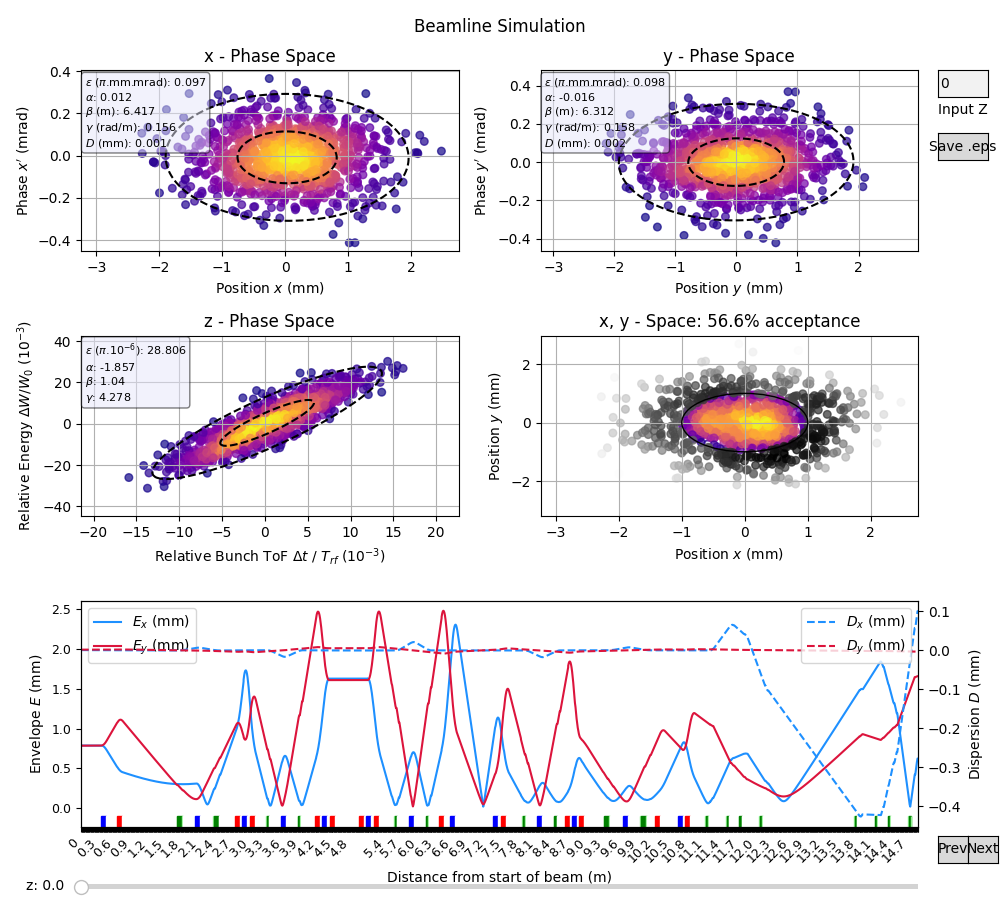

,$\epsilon$ ($\pi$.mm.mrad),$\alpha$,$\beta$ (m),$\gamma$ (rad/m),$D$ (mm),$D^{\prime}$ (mrad),$\phi$ (deg),Envelope $E$ (mm)
x,"[0.09654341638088226, 0.09654336422681808, 0.0...","[0.01243884488940239, 0.010880270041525364, 0....","[6.417181015014648, 6.41694450378418, 6.416743...","[0.15585575997829437, 0.15585584938526154, 0.1...","[0.000657698605209589, 0.0006546537042595446, ...","[-0.00030455185333266854, -0.00030455185333266...","[89.88617706298828, 89.90043640136719, 89.9146...","[0.7871064595872986, 0.787091742081007, 0.7870..."
y,"[0.09754621982574463, 0.09754623472690582, 0.0...","[-0.016351085156202316, -0.017935846000909805,...","[6.311820030212402, 6.312164306640625, 6.31254...","[0.15847525000572205, 0.15847523510456085, 0.1...","[0.0017957825912162662, 0.001792742172256112, ...","[-0.0003039091534446925, -0.000303909153444692...","[-89.8477554321289, -89.8330078125, -89.818267...","[0.7846618279027194, 0.7846832871231317, 0.784..."
z,"[28.805885314941406, 28.805877685546875, 28.80...","[-1.8569321632385254, -1.8568675518035889, -1....","[1.0397480726242065, 1.0396918058395386, 1.039...","[4.278148651123047, 4.278149604797363, 4.27813...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-24.4561767578125, -24.455432891845703, -24.4...","[5.472738230213854, 5.472589422721121, 5.47244..."


In [ ]:
%load_ext autotime
# Display Optimized Beamline

%matplotlib ipympl
acceptance = {"shape":'circle', "radius":1, "origin":[0,0]}
schem.plotBeamPositionTransform(beam_dist, line, 0.01, plot=True, showIndice=False, 
                                defineLim=False, matchScaling=False, shape=acceptance, scatter=True)

